# Effect Size Comparison: Pre vs Post Case-Control Matching
## SAMPLE-SIZE CONTROLLED VERSION

This notebook provides a **fair comparison** of effect sizes before and after case-control matching by:

1. **Subsampling pre-CCM** to match post-CCM sample sizes (random subsampling)
2. **Bootstrap iterations** to get confidence intervals for pre-CCM effect sizes
3. **Proper statistical testing** comparing distributions of effect sizes

This addresses the critical issue that PERMANOVA R² is sensitive to sample size imbalance.

## 1. Setup and Imports

In [1]:
# Core imports
import pandas as pd
import numpy as np
import warnings
import os
warnings.filterwarnings('ignore')

# QIIME2 imports
from qiime2 import Artifact, Metadata
from qiime2.plugins.diversity.actions import beta_phylogenetic, beta
from qiime2.plugins.feature_table.methods import filter_samples

# QUPID imports
import qupid
from qupid import match_by_multiple
from qupid.casematch import CaseMatchOneToMany, CaseMatchOneToOne, CaseMatchCollection

# Statistical imports
from scipy import stats
from skbio.stats.distance import DistanceMatrix, permanova

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 2. Configuration

In [2]:
# Dataset name
DATASET_NAME = "HMP2"

# File paths — override via env vars so the notebook runs on any host.
FEATURE_TABLE_PATH = os.environ.get("HMP2_FEATURE_TABLE", "72996_gg2_2024_9.qza")
METADATA_PATH = os.environ.get(
    "HMP2_METADATA",
    "/Users/leojo/Developer/knight_lab/ms_thesis/microbiome_mechinterp/"
    "prelim_analysis/data/metadata/72996_72996_analysis_mapping.txt",
)
TREE_PATH = os.environ.get(
    "HMP2_TREE",
    "/Users/leojo/Developer/knight_lab/pierce_autism_2024/ref/gg2/"
    "2024.09.phylogeny.asv.nwk",
)

# Case-control configuration
CASE_CONTROL_COLUMN = 'diagnosis'
CASE_VALUES = ['UC', 'CD']
CONTROL_VALUE = 'nonIBD'

# Matching criteria
MATCHING_CATEGORIES = ['sex', 'race', 'site_name']
# consent_age dropped in v2 — age tolerance made matching too restrictive
NUMERIC_CATEGORIES = []
TOLERANCE_MAP = {}

# Effect size categories (consent_age dropped to align with v2 matching)
EFFECT_SIZE_CATEGORIES = [
    'sex', 'race', 'hispanic_or_latino_origin', 'education_level',
    'site_name', 'diagnosis', 'age_at_diagnosis', 'baseline_montreal_location',
    'antibiotics', 'probiotic', 'abdominal_pain', 'blood_in_the_stool',
    'bowel_frequency_during_the_day', 'general_wellbeing',
]

# Analysis parameters
N_ITERATIONS = 100          # Number of CCM iterations
N_BOOTSTRAP = 100           # Number of bootstrap iterations for pre-CCM
N_PERMUTATIONS = 999        # Permutations for PERMANOVA
RANDOM_SEED = 42

OUTPUT_DIR = 'hmp2_ccm_analysis_controlled_v2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.random.seed(RANDOM_SEED)

## 3. Data Loading

In [3]:
def load_data(feature_table_path, metadata_path):
    """Load feature table and metadata."""
    if feature_table_path.endswith('.qza'):
        table_artifact = Artifact.load(feature_table_path)
    elif feature_table_path.endswith('.biom'):
        table_artifact = Artifact.import_data('FeatureTable[Frequency]', feature_table_path)
    else:
        raise ValueError("Feature table must be .qza or .biom format")
    
    metadata = Metadata.load(metadata_path)
    table_df = table_artifact.view(pd.DataFrame)
    metadata_df = metadata.to_dataframe()
    
    return table_artifact, metadata, table_df, metadata_df

def prepare_case_control_groups(metadata_df, case_control_col, case_values, control_value):
    """Separate metadata into focus (cases) and background (controls)."""
    if isinstance(case_values, str):
        case_values = [case_values]
    
    all_values = case_values + [control_value]
    relevant_samples = metadata_df[metadata_df[case_control_col].isin(all_values)].copy()
    relevant_samples['is_case'] = relevant_samples[case_control_col].isin(case_values).astype(int)
    
    focus = relevant_samples[relevant_samples['is_case'] == 1]
    background = relevant_samples[relevant_samples['is_case'] == 0]
    
    print(f"Cases (focus): {len(focus)} samples")
    print(f"Controls (background): {len(background)} samples")
    
    return focus, background, relevant_samples

# Load data
print("Loading data...")
table_artifact, metadata, table_df, metadata_df = load_data(FEATURE_TABLE_PATH, METADATA_PATH)
print(f"Feature table shape: {table_df.shape}")
print(f"Metadata shape: {metadata_df.shape}")

# Prepare case-control groups
focus, background, all_relevant = prepare_case_control_groups(
    metadata_df, CASE_CONTROL_COLUMN, CASE_VALUES, CONTROL_VALUE
)

# Filter to common samples
common_samples = list(set(all_relevant.index) & set(table_df.index))
all_relevant = all_relevant.loc[all_relevant.index.isin(common_samples)]
focus = focus.loc[focus.index.isin(common_samples)]
background = background.loc[background.index.isin(common_samples)]

print(f"\nAfter filtering to feature table:")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")

Loading data...


Feature table shape: (1592, 9045)
Metadata shape: (1592, 383)
Cases (focus): 1179 samples
Controls (background): 413 samples

After filtering to feature table:
  Cases: 1179
  Controls: 413


## 4. Compute Distance Matrix

In [4]:
def compute_distance_matrix(table_artifact, metric='braycurtis', tree_path=None, sample_ids=None):
    """Compute beta diversity distance matrix."""
    if sample_ids is not None:
        filter_md = pd.DataFrame(index=sample_ids)
        filter_md['keep'] = 'yes'
        filter_md.index.name = 'sample-id'
        filter_metadata = Metadata(filter_md)
        table_artifact = filter_samples(table=table_artifact, metadata=filter_metadata).filtered_table
    
    if metric in ['unweighted_unifrac', 'weighted_unifrac']:
        if tree_path is None:
            raise ValueError("Tree required for UniFrac metrics")
        tree = Artifact.import_data("Phylogeny[Rooted]", tree_path)
        dm_artifact = beta_phylogenetic(table=table_artifact, phylogeny=tree, metric=metric).distance_matrix
    else:
        dm_artifact = beta(table=table_artifact, metric=metric).distance_matrix
    
    dm = dm_artifact.view(DistanceMatrix)
    return dm_artifact, dm

# Compute distance matrix
print("Computing distance matrix...")
if TREE_PATH:
    print("Using Unweighted UniFrac")
    dm_artifact, dm_full = compute_distance_matrix(
        table_artifact, metric='unweighted_unifrac', tree_path=TREE_PATH, sample_ids=common_samples
    )
    DISTANCE_METRIC = 'Unweighted UniFrac'
else:
    print("Using Bray-Curtis")
    dm_artifact, dm_full = compute_distance_matrix(
        table_artifact, metric='braycurtis', sample_ids=common_samples
    )
    DISTANCE_METRIC = 'Bray-Curtis'

print(f"Distance matrix computed: {dm_full.shape[0]} samples")

Computing distance matrix...
Using Unweighted UniFrac


Running external command line application. This may print messages to stdout and/or stderr.
The command being run is below. This command cannot be manually re-run as it will depend on temporary files that no longer exist.

Command:

ssu -i /var/folders/tx/vgccmrkj1fz1zv99j496_3k80000gn/T/qiime2/leojo/data/2a5e2515-446d-492d-b0b3-b3f58001ef57/data/feature-table.biom -t /var/folders/tx/vgccmrkj1fz1zv99j496_3k80000gn/T/qiime2/leojo/data/f2402b87-4feb-4c11-b2e6-eea2853eb0c2/data/tree.nwk -m unweighted -o /var/folders/tx/vgccmrkj1fz1zv99j496_3k80000gn/T/q2-LSMatFormat-j45rp979



Distance matrix computed: 1592 samples


## 5. Effect Size Calculation Functions

In [5]:
def calculate_effect_size_permanova(dm, metadata_df, category, permutations=999):
    """
    Calculate effect size (R²) using PERMANOVA.
    
    Returns the true R² (proportion of variance explained), not the pseudo-F statistic.
    
    R² = (F × df_between) / (F × df_between + df_within)
    
    where:
        df_between = n_groups - 1
        df_within = n_samples - n_groups
    """
    common_ids = list(set(dm.ids) & set(metadata_df.index))
    
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm.filter(common_ids)
    md_filtered = metadata_df.loc[common_ids, [category]].dropna()
    
    common_ids = list(set(dm_filtered.ids) & set(md_filtered.index))
    if len(common_ids) < 10:
        return None
    
    dm_filtered = dm_filtered.filter(common_ids)
    md_filtered = md_filtered.loc[common_ids]
    
    grouping = md_filtered[category]
    n_groups = grouping.nunique()
    n_samples = len(common_ids)
    
    if n_groups < 2:
        return None
    
    try:
        results = permanova(dm_filtered, grouping, permutations=permutations)
        
        # Extract pseudo-F statistic
        pseudo_f = results['test statistic']
        
        # Convert pseudo-F to R² (proportion of variance explained)
        df_between = n_groups - 1
        df_within = n_samples - n_groups
        r_squared = (pseudo_f * df_between) / (pseudo_f * df_between + df_within)
        
        # Return as percentage for easier interpretation
        r_squared_pct = r_squared * 100
        
        return {
            'r_squared': r_squared_pct,      # Now correctly R² as percentage
            'pseudo_f': pseudo_f,             # Also return F for reference
            'p_value': results['p-value'],
            'n_samples': n_samples,
            'n_groups': n_groups
        }
    except Exception as e:
        return None

## 6. Case-Control Matching

In [6]:
def perform_case_control_matching(focus, background, categories, tolerance_map=None, 
                                   n_iterations=100, numeric_categories=None):
    """Perform case-control matching using QUPID."""
    if numeric_categories is None:
        numeric_categories = []
    
    all_cats = categories + [c for c in numeric_categories if c not in categories]
    
    focus_clean = focus.dropna(subset=all_cats)
    background_clean = background.dropna(subset=all_cats)
    
    print(f"After cleaning:")
    print(f"  Cases: {len(focus_clean)} (dropped {len(focus) - len(focus_clean)})")
    print(f"  Controls: {len(background_clean)} (dropped {len(background) - len(background_clean)})")
    
    if tolerance_map is None:
        tolerance_map = {}
    
    cm = match_by_multiple(
        focus=focus_clean,
        background=background_clean,
        categories=all_cats,
        tolerance_map=tolerance_map,
        on_failure='ignore'
    )
    
    print(f"\nMatching results:")
    print(f"  Matched cases: {len(cm.cases)}")
    print(f"  Available controls: {len(cm.controls)}")
    
    matched_pairs = cm.create_matched_pairs(iterations=n_iterations, strict=False)
    
    return cm, matched_pairs, focus_clean, background_clean

# Perform matching
print("Performing case-control matching...")
cm, matched_pairs, focus_clean, background_clean = perform_case_control_matching(
    focus, background,
    categories=MATCHING_CATEGORIES,
    tolerance_map=TOLERANCE_MAP,
    n_iterations=N_ITERATIONS,
    numeric_categories=NUMERIC_CATEGORIES
)

Performing case-control matching...
After cleaning:
  Cases: 1179 (dropped 0)
  Controls: 413 (dropped 0)



Matching results:
  Matched cases: 1179
  Available controls: 403


## 7. Determine Target Sample Size from CCM

In [7]:
# Get sample sizes from CCM to use for fair comparison
cm_single = matched_pairs[0]
n_cases_matched = len(list(cm_single.cases))
n_controls_matched = len(list(cm_single.controls))

print("=== Sample Size Check ===")
print(f"\nPre-CCM (Full dataset):")
print(f"  Total samples: {len(all_relevant)}")
print(f"  Cases: {len(focus)}")
print(f"  Controls: {len(background)}")
print(f"  Ratio: {len(focus)/len(background):.2f}")

print(f"\nPost-CCM (Matched):")
print(f"  Cases: {n_cases_matched}")
print(f"  Controls: {n_controls_matched}")
print(f"  Ratio: {n_cases_matched/n_controls_matched:.2f}")

# Target sample size for fair comparison
TARGET_N_CASES = n_cases_matched
TARGET_N_CONTROLS = n_controls_matched
TARGET_TOTAL = TARGET_N_CASES + TARGET_N_CONTROLS

print(f"\n==> Target sample size for Pre-CCM bootstrap: {TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")

=== Sample Size Check ===

Pre-CCM (Full dataset):
  Total samples: 1592
  Cases: 1179
  Controls: 413
  Ratio: 2.85

Post-CCM (Matched):
  Cases: 323
  Controls: 323
  Ratio: 1.00

==> Target sample size for Pre-CCM bootstrap: 323 cases + 323 controls = 646 total


## 8. Sample-Size Controlled Pre-CCM Effect Sizes (Bootstrap)

**Key Innovation**: Instead of computing pre-CCM effect sizes on the full imbalanced dataset, we:
1. Randomly subsample to match the post-CCM sample size
2. Repeat this N_BOOTSTRAP times
3. Get a distribution of pre-CCM effect sizes for fair comparison

In [8]:
def calculate_bootstrap_effect_sizes(dm, metadata_df, categories, 
                                      n_cases, n_controls, 
                                      n_bootstrap=100, permutations=999,
                                      random_seed=42):
    """
    Calculate effect sizes using bootstrap subsampling to control for sample size.
    
    This gives a fair comparison by matching the sample size of the CCM analysis.
    """
    np.random.seed(random_seed)
    
    # Get case and control indices
    case_ids = metadata_df[metadata_df['is_case'] == 1].index.tolist()
    control_ids = metadata_df[metadata_df['is_case'] == 0].index.tolist()
    
    # Filter to samples in distance matrix
    case_ids = [s for s in case_ids if s in dm.ids]
    control_ids = [s for s in control_ids if s in dm.ids]
    
    print(f"Available for subsampling: {len(case_ids)} cases, {len(control_ids)} controls")
    print(f"Target: {n_cases} cases, {n_controls} controls")
    
    # Adjust if we don't have enough samples
    n_cases = min(n_cases, len(case_ids))
    n_controls = min(n_controls, len(control_ids))
    
    all_results = []
    
    print(f"\nRunning {n_bootstrap} bootstrap iterations...")
    
    for i in range(n_bootstrap):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_bootstrap}")
        
        # Random subsample (without replacement)
        sampled_cases = np.random.choice(case_ids, size=n_cases, replace=False)
        sampled_controls = np.random.choice(control_ids, size=n_controls, replace=False)
        sampled_ids = list(sampled_cases) + list(sampled_controls)
        
        # Filter distance matrix and metadata
        dm_sub = dm.filter(sampled_ids)
        md_sub = metadata_df.loc[sampled_ids]
        
        # Calculate effect sizes for each category
        for cat in categories:
            if cat not in md_sub.columns:
                continue
            
            effect = calculate_effect_size_permanova(dm_sub, md_sub, cat, permutations=permutations)
            
            if effect is not None:
                all_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],
                    'n_samples': effect['n_samples'],
                    'n_groups': effect['n_groups']
                })
    
    results_df = pd.DataFrame(all_results)
    
    # Summarize
    if len(results_df) > 0:
        summary = results_df.groupby('category').agg({
            'r_squared': ['mean', 'std', 'min', 'max'],
            'p_value': 'mean',
            'n_samples': 'mean'
        }).reset_index()
        summary.columns = ['category', 'r_squared_mean', 'r_squared_std', 
                          'r_squared_min', 'r_squared_max', 'p_value', 'n_samples']
        summary['condition'] = 'Pre-CCM (bootstrap)'
    else:
        summary = pd.DataFrame()
    
    return results_df, summary

In [9]:
# Calculate sample-size controlled Pre-CCM effect sizes
print("Calculating SAMPLE-SIZE CONTROLLED Pre-CCM effect sizes...")
print("(Using bootstrap subsampling to match CCM sample size)\n")

effect_sizes_pre_all, effect_sizes_pre = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED
)

print(f"\nPre-CCM effect sizes calculated for {len(effect_sizes_pre)} categories")
effect_sizes_pre.sort_values('r_squared_mean', ascending=False)

Calculating SAMPLE-SIZE CONTROLLED Pre-CCM effect sizes...
(Using bootstrap subsampling to match CCM sample size)

Available for subsampling: 1179 cases, 413 controls
Target: 323 cases, 323 controls

Running 100 bootstrap iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



Pre-CCM effect sizes calculated for 14 categories


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
1,age_at_diagnosis,26.490883,1.622128,22.598360,30.350068,0.00100,319.98,Pre-CCM (bootstrap)
3,baseline_montreal_location,6.978517,0.721085,5.673762,9.010125,0.00101,174.34,Pre-CCM (bootstrap)
4,blood_in_the_stool,6.288240,1.454475,2.671801,10.782314,0.01007,121.85,Pre-CCM (bootstrap)
5,bowel_frequency_during_the_day,5.893908,2.061009,1.959202,11.592782,0.01251,121.85,Pre-CCM (bootstrap)
7,education_level,5.281641,0.299476,4.443235,6.001294,0.00100,629.41,Pre-CCM (bootstrap)
13,site_name,3.702838,0.245923,3.141666,4.334204,0.00100,646.00,Pre-CCM (bootstrap)
6,diagnosis,2.457367,0.282016,1.934623,3.311179,0.00100,646.00,Pre-CCM (bootstrap)
8,general_wellbeing,2.277165,0.530058,1.308008,3.897858,0.29926,192.14,Pre-CCM (bootstrap)
11,race,1.995768,0.462463,1.061668,3.073984,0.00238,646.00,Pre-CCM (bootstrap)
0,abdominal_pain,1.921988,0.422679,1.150018,3.175664,0.20514,192.14,Pre-CCM (bootstrap)


## 9. Post-CCM Effect Sizes

In [10]:
def calculate_matched_effect_sizes(matched_pairs, dm, metadata_df, categories, 
                                    permutations=999, n_iterations_to_use=None):
    """Calculate effect sizes for multiple matched pair iterations."""
    all_results = []
    
    if n_iterations_to_use is None:
        n_iterations_to_use = len(matched_pairs.case_matches)
    n_use = min(n_iterations_to_use, len(matched_pairs.case_matches))
    
    print(f"Calculating effect sizes for {n_use} CCM iterations...")
    
    for i in range(n_use):
        if (i + 1) % 20 == 0:
            print(f"  Iteration {i + 1}/{n_use}")
        
        cm_single = matched_pairs[i]
        
        cases = list(cm_single.cases)
        controls = list(cm_single.controls)
        matched_samples = [s for s in cases + controls if s in dm.ids]
        
        if len(matched_samples) < 20:
            continue
        
        dm_matched = dm.filter(matched_samples)
        md_matched = metadata_df.loc[metadata_df.index.isin(matched_samples)]
        
        for cat in categories:
            if cat not in md_matched.columns:
                continue
            
            effect = calculate_effect_size_permanova(dm_matched, md_matched, cat, permutations=permutations)
            
            if effect is not None:
                all_results.append({
                    'iteration': i,
                    'category': cat,
                    'r_squared': effect['r_squared'],
                    'p_value': effect['p_value'],
                    'n_samples': effect['n_samples']
                })
    
    results_df = pd.DataFrame(all_results)
    
    if len(results_df) > 0:
        summary = results_df.groupby('category').agg({
            'r_squared': ['mean', 'std', 'min', 'max'],
            'p_value': 'mean',
            'n_samples': 'mean'
        }).reset_index()
        summary.columns = ['category', 'r_squared_mean', 'r_squared_std',
                          'r_squared_min', 'r_squared_max', 'p_value', 'n_samples']
        summary['condition'] = 'Post-CCM'
    else:
        summary = pd.DataFrame()
    
    return results_df, summary

In [11]:
# Calculate Post-CCM effect sizes
print("Calculating Post-CCM effect sizes...\n")

effect_sizes_post_all, effect_sizes_post = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    EFFECT_SIZE_CATEGORIES,
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS  # Use same number as bootstrap
)

print(f"\nPost-CCM effect sizes calculated")
effect_sizes_post.sort_values('r_squared_mean', ascending=False)

Calculating Post-CCM effect sizes...

Calculating effect sizes for 100 CCM iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



Post-CCM effect sizes calculated


,category,r_squared_mean,r_squared_std,r_squared_min,r_squared_max,p_value,n_samples,condition
1,age_at_diagnosis,28.590853,0.000000,28.590853,28.590853,0.00100,323.00,Post-CCM
5,bowel_frequency_during_the_day,14.061748,0.000000,14.061748,14.061748,0.00100,113.00,Post-CCM
3,baseline_montreal_location,8.775938,0.000000,8.775938,8.775938,0.00100,210.00,Post-CCM
7,education_level,5.504619,0.138977,5.109254,5.795175,0.00100,639.93,Post-CCM
4,blood_in_the_stool,5.364829,0.000000,5.364829,5.364829,0.02338,113.00,Post-CCM
12,site_name,3.659100,0.056934,3.495082,3.798729,0.00100,646.00,Post-CCM
8,general_wellbeing,3.376785,0.000000,3.376785,3.376785,0.00819,203.00,Post-CCM
0,abdominal_pain,3.186702,0.000000,3.186702,3.186702,0.00171,203.00,Post-CCM
6,diagnosis,2.447249,0.065933,2.299742,2.690952,0.00100,646.00,Post-CCM
2,antibiotics,1.162086,0.018878,1.124504,1.235942,0.00100,646.00,Post-CCM


## 10. Case-Control Effect Sizes (is_case variable)

In [12]:
# Pre-CCM case-control effect (bootstrap)
print("Calculating case-control effect sizes...\n")

cc_pre_all, cc_pre_summary = calculate_bootstrap_effect_sizes(
    dm_full,
    all_relevant,
    ['is_case'],
    n_cases=TARGET_N_CASES,
    n_controls=TARGET_N_CONTROLS,
    n_bootstrap=N_BOOTSTRAP,
    permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED + 1  # Different seed for variety
)

# Post-CCM case-control effect
cc_post_all, cc_post_summary = calculate_matched_effect_sizes(
    matched_pairs,
    dm_full,
    all_relevant,
    ['is_case'],
    permutations=N_PERMUTATIONS,
    n_iterations_to_use=N_ITERATIONS
)

print(f"\n=== Case-Control Effect Size (Sample-Size Controlled) ===")
print(f"Pre-CCM (bootstrap): R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM:            R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

Calculating case-control effect sizes...

Available for subsampling: 1179 cases, 413 controls
Target: 323 cases, 323 controls

Running 100 bootstrap iterations...


  Iteration 20/100


  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


...

  Iteration 40/100


  Iteration 60/100


  Iteration 80/100


  Iteration 100/100



=== Case-Control Effect Size (Sample-Size Controlled) ===
Pre-CCM (bootstrap): R² = 2.0013 ± 0.2003
Post-CCM:            R² = 1.9012 ± 0.0652


## 11. Statistical Comparison (Fair Test)

In [13]:
def compare_effect_sizes_fair(pre_all_df, post_all_df):
    """
    Compare pre and post CCM effect sizes using proper statistical tests.
    Both pre and post now have distributions from bootstrap/iterations.
    """
    results = []
    
    categories = set(pre_all_df['category'].unique()) & set(post_all_df['category'].unique())
    
    for cat in categories:
        pre_vals = pre_all_df[pre_all_df['category'] == cat]['r_squared'].values
        post_vals = post_all_df[post_all_df['category'] == cat]['r_squared'].values
        
        if len(pre_vals) < 2 or len(post_vals) < 2:
            continue
        
        # Two-sample t-test (are they different?)
        t_stat, p_val_two = stats.ttest_ind(pre_vals, post_vals)
        
        # Mann-Whitney U test (non-parametric)
        u_stat, p_val_mw = stats.mannwhitneyu(pre_vals, post_vals, alternative='two-sided')
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt((pre_vals.std()**2 + post_vals.std()**2) / 2)
        cohens_d = (post_vals.mean() - pre_vals.mean()) / pooled_std if pooled_std > 0 else 0
        
        results.append({
            'category': cat,
            'pre_mean': pre_vals.mean(),
            'pre_std': pre_vals.std(),
            'post_mean': post_vals.mean(),
            'post_std': post_vals.std(),
            'delta': post_vals.mean() - pre_vals.mean(),
            'pct_change': ((post_vals.mean() - pre_vals.mean()) / pre_vals.mean() * 100) if pre_vals.mean() > 0 else 0,
            't_statistic': t_stat,
            'p_value_ttest': p_val_two,
            'p_value_mannwhitney': p_val_mw,
            'cohens_d': cohens_d,
            'significant': p_val_two < 0.05
        })
    
    return pd.DataFrame(results)

In [14]:
# Compare effect sizes
comparison_df = compare_effect_sizes_fair(effect_sizes_pre_all, effect_sizes_post_all)

print("=== Effect Size Comparison (Sample-Size Controlled) ===")
print("\nNote: Pre-CCM values are now from bootstrap subsampling to match CCM sample size")
print(comparison_df.sort_values('pre_mean', ascending=False).to_string())

=== Effect Size Comparison (Sample-Size Controlled) ===

Note: Pre-CCM values are now from bootstrap subsampling to match CCM sample size
                          category   pre_mean   pre_std  post_mean      post_std     delta  pct_change  t_statistic  p_value_ttest  p_value_mannwhitney  cohens_d  significant
10                age_at_diagnosis  26.490883  1.613997  28.590853  3.552714e-15  2.099971    7.927145   -12.945776   3.572332e-28         5.361279e-28  1.840032         True
12      baseline_montreal_location   6.978517  0.717470   8.775938  0.000000e+00  1.797421   25.756489   -24.926626   5.617118e-63         1.684903e-37  3.542916         True
7               blood_in_the_stool   6.288240  1.447184   5.364829  8.881784e-16 -0.923411  -14.684734     6.348763   1.452786e-09         4.156760e-08 -0.902374         True
1   bowel_frequency_during_the_day   5.893908  2.050678  14.061748  1.776357e-15  8.167840  138.581048   -39.630293   4.305846e-96         5.640015e-39  5.632805 

In [15]:
# Case-control comparison
print("\n=== Case-Control Effect Size Comparison ===")

pre_cc = cc_pre_all['r_squared'].values
post_cc = cc_post_all['r_squared'].values

t_stat, p_val = stats.ttest_ind(pre_cc, post_cc)
u_stat, p_val_mw = stats.mannwhitneyu(pre_cc, post_cc, alternative='two-sided')

print(f"\nPre-CCM (bootstrap, n={len(pre_cc)}):  R² = {pre_cc.mean():.4f} ± {pre_cc.std():.4f}")
print(f"Post-CCM (n={len(post_cc)}):           R² = {post_cc.mean():.4f} ± {post_cc.std():.4f}")
print(f"\nDelta: {post_cc.mean() - pre_cc.mean():.4f} ({(post_cc.mean() - pre_cc.mean())/pre_cc.mean()*100:.1f}%)")
print(f"\nStatistical Tests:")
print(f"  t-test: t={t_stat:.3f}, p={p_val:.4e}")
print(f"  Mann-Whitney U: p={p_val_mw:.4e}")
print(f"\nInterpretation: {'Significant difference' if p_val < 0.05 else 'No significant difference'}")


=== Case-Control Effect Size Comparison ===

Pre-CCM (bootstrap, n=100):  R² = 2.0013 ± 0.1993
Post-CCM (n=100):           R² = 1.9012 ± 0.0649

Delta: -0.1001 (-5.0%)

Statistical Tests:
  t-test: t=4.753, p=3.8494e-06
  Mann-Whitney U: p=1.1880e-05

Interpretation: Significant difference


## 12. Visualization (Sample-Size Controlled)

Saved figure to hmp2_ccm_analysis_controlled_v2/HMP2_effect_size_controlled.png


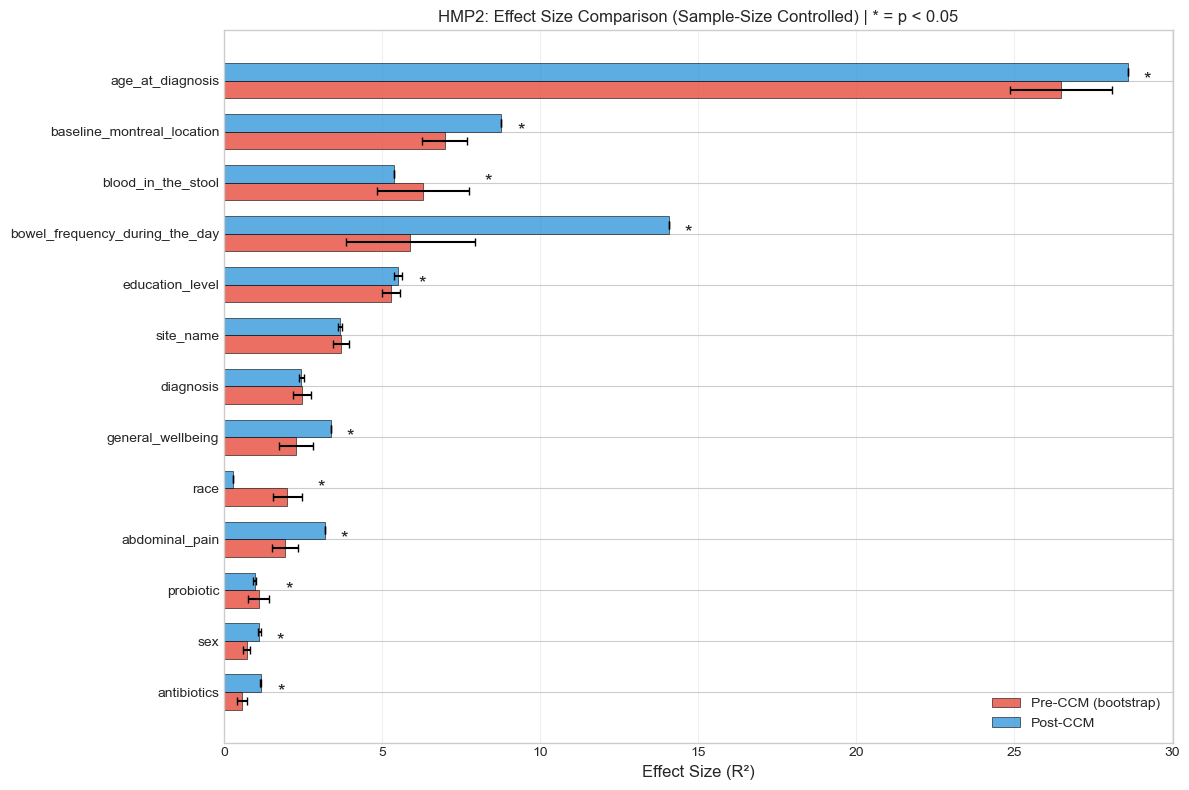

In [16]:
def plot_effect_size_comparison_controlled(comparison_df, dataset_name, output_path=None):
    """
    Create side-by-side bar chart with error bars for fair comparison.
    """
    # Sort by pre-CCM effect size
    plot_data = comparison_df.sort_values('pre_mean', ascending=True).tail(15)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    y_pos = np.arange(len(plot_data))
    height = 0.35
    
    # Pre-CCM bars with error bars
    bars1 = ax.barh(y_pos - height/2, plot_data['pre_mean'], height, 
                    xerr=plot_data['pre_std'], capsize=3,
                    label='Pre-CCM (bootstrap)', color='#e74c3c', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    # Post-CCM bars with error bars
    bars2 = ax.barh(y_pos + height/2, plot_data['post_mean'], height,
                    xerr=plot_data['post_std'], capsize=3,
                    label='Post-CCM', color='#3498db', alpha=0.8,
                    edgecolor='black', linewidth=0.5)
    
    # Add significance markers
    for i, (_, row) in enumerate(plot_data.iterrows()):
        if row['significant']:
            max_val = max(row['pre_mean'] + row['pre_std'], row['post_mean'] + row['post_std'])
            ax.text(max_val + 0.5, y_pos[i], '*', fontsize=14, ha='left', va='center')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(plot_data['category'], fontsize=10)
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_title(f'{dataset_name}: Effect Size Comparison (Sample-Size Controlled) | * = p < 0.05',
                 fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved figure to {output_path}")
    
    plt.show()
    
    return fig

# Create comparison figure
fig1 = plot_effect_size_comparison_controlled(
    comparison_df,
    DATASET_NAME,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_effect_size_controlled.png')
)

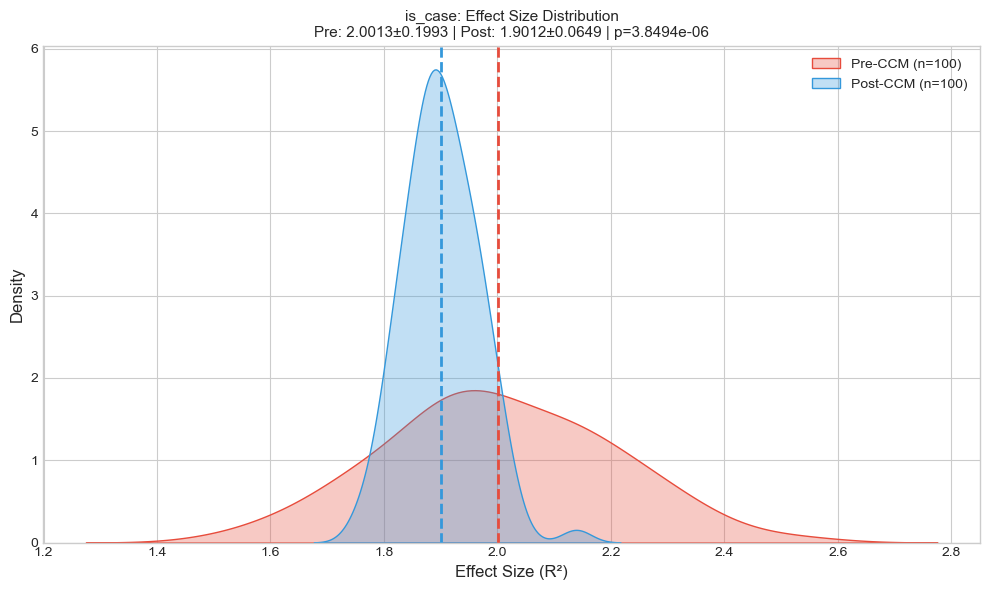

In [17]:
def plot_distribution_comparison(pre_all_df, post_all_df, category, output_path=None):
    """
    Plot overlapping distributions of effect sizes for a specific category.
    """
    pre_vals = pre_all_df[pre_all_df['category'] == category]['r_squared'].values
    post_vals = post_all_df[post_all_df['category'] == category]['r_squared'].values
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot distributions
    sns.kdeplot(pre_vals, ax=ax, color='#e74c3c', fill=True, alpha=0.3, 
                label=f'Pre-CCM (n={len(pre_vals)})')
    sns.kdeplot(post_vals, ax=ax, color='#3498db', fill=True, alpha=0.3,
                label=f'Post-CCM (n={len(post_vals)})')
    
    # Add means
    ax.axvline(pre_vals.mean(), color='#e74c3c', linestyle='--', linewidth=2)
    ax.axvline(post_vals.mean(), color='#3498db', linestyle='--', linewidth=2)
    
    # Statistical test
    t_stat, p_val = stats.ttest_ind(pre_vals, post_vals)
    
    ax.set_xlabel('Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{category}: Effect Size Distribution\n'
                 f'Pre: {pre_vals.mean():.4f}±{pre_vals.std():.4f} | '
                 f'Post: {post_vals.mean():.4f}±{post_vals.std():.4f} | '
                 f'p={p_val:.4e}', fontsize=11)
    ax.legend()
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.show()
    
    return fig

# Plot case-control distribution
fig2 = plot_distribution_comparison(
    cc_pre_all, cc_post_all, 'is_case',
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_case_control_distribution.png')
)

Saved figure to hmp2_ccm_analysis_controlled_v2/HMP2_scatter_comparison.png


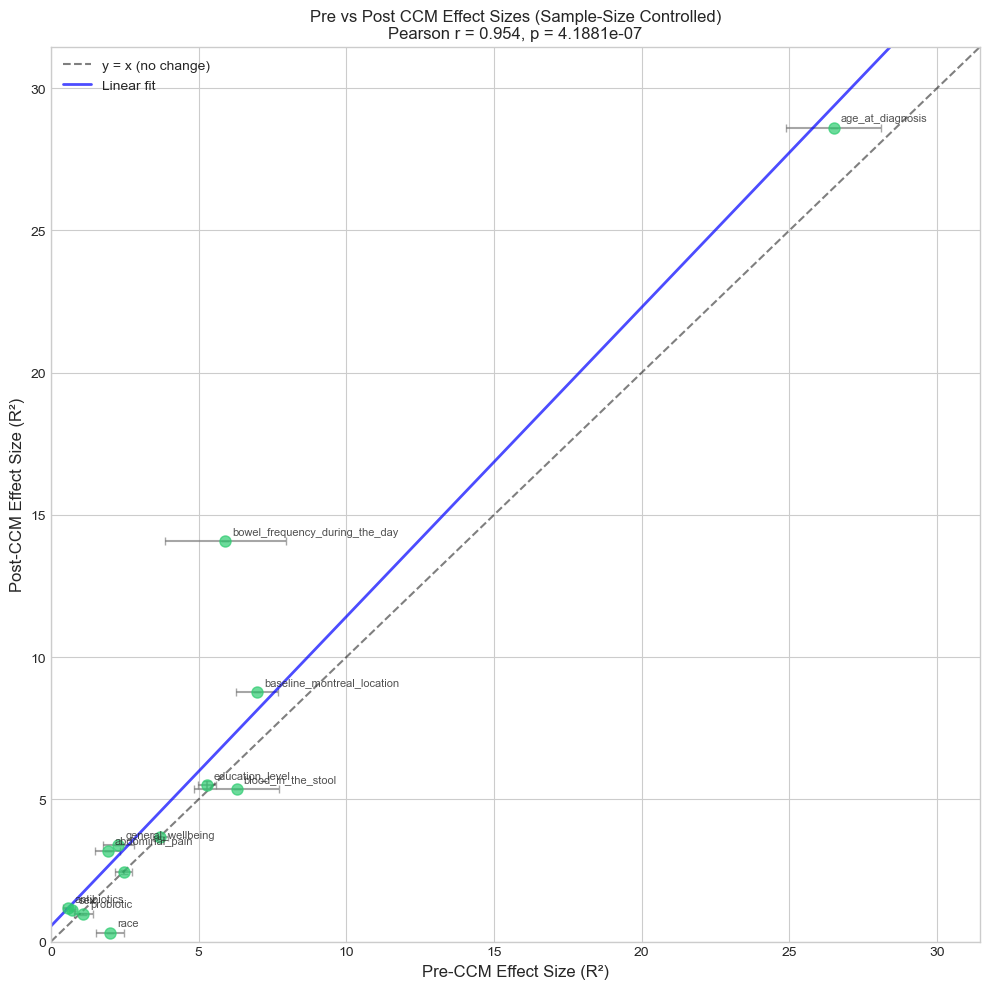

In [18]:
def plot_scatter_comparison(comparison_df, output_path=None):
    """
    Scatter plot comparing Pre vs Post CCM effect sizes with error bars.
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot with error bars
    ax.errorbar(comparison_df['pre_mean'], comparison_df['post_mean'],
                xerr=comparison_df['pre_std'], yerr=comparison_df['post_std'],
                fmt='o', markersize=8, capsize=3, alpha=0.7,
                color='#2ecc71', ecolor='gray')
    
    # Identity line
    max_val = max(comparison_df['pre_mean'].max(), comparison_df['post_mean'].max()) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='y = x (no change)')
    
    # Regression line
    z = np.polyfit(comparison_df['pre_mean'], comparison_df['post_mean'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, max_val, 100)
    ax.plot(x_line, p(x_line), 'b-', alpha=0.7, linewidth=2, label='Linear fit')
    
    # Add labels for significant changes
    for _, row in comparison_df.iterrows():
        if row['significant']:
            ax.annotate(row['category'], 
                       (row['pre_mean'], row['post_mean']),
                       fontsize=8, alpha=0.8,
                       xytext=(5, 5), textcoords='offset points')
    
    # Correlation
    corr, p_corr = stats.pearsonr(comparison_df['pre_mean'], comparison_df['post_mean'])
    
    ax.set_xlabel('Pre-CCM Effect Size (R²)', fontsize=12)
    ax.set_ylabel('Post-CCM Effect Size (R²)', fontsize=12)
    ax.set_title(f'Pre vs Post CCM Effect Sizes (Sample-Size Controlled)\n'
                 f'Pearson r = {corr:.3f}, p = {p_corr:.4e}', fontsize=12)
    ax.legend(loc='upper left')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Saved figure to {output_path}")
    
    plt.show()
    
    return fig

# Create scatter plot
fig3 = plot_scatter_comparison(
    comparison_df,
    output_path=os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_scatter_comparison.png')
)

## 13. Summary

In [19]:
print("\n" + "="*70)
print(f"SUMMARY: {DATASET_NAME} Effect Size Analysis (SAMPLE-SIZE CONTROLLED)")
print("="*70)

print(f"\nDataset: {DATASET_NAME}")
print(f"Distance Metric: {DISTANCE_METRIC}")
print(f"Matching Categories: {MATCHING_CATEGORIES}")

print(f"\n--- Sample Sizes ---")
print(f"Original: {len(focus)} cases + {len(background)} controls = {len(all_relevant)} total")
print(f"Analysis: {TARGET_N_CASES} cases + {TARGET_N_CONTROLS} controls = {TARGET_TOTAL} total")
print(f"Bootstrap iterations (Pre-CCM): {N_BOOTSTRAP}")
print(f"CCM iterations (Post-CCM): {N_ITERATIONS}")

print(f"\n--- Case-Control Effect Size ---")
print(f"Pre-CCM (bootstrap):  R² = {cc_pre_all['r_squared'].mean():.4f} ± {cc_pre_all['r_squared'].std():.4f}")
print(f"Post-CCM:             R² = {cc_post_all['r_squared'].mean():.4f} ± {cc_post_all['r_squared'].std():.4f}")

delta = cc_post_all['r_squared'].mean() - cc_pre_all['r_squared'].mean()
pct = delta / cc_pre_all['r_squared'].mean() * 100
print(f"Change: {delta:+.4f} ({pct:+.1f}%)")

t_stat, p_val = stats.ttest_ind(cc_pre_all['r_squared'].values, cc_post_all['r_squared'].values)
print(f"Statistical significance: p = {p_val:.4e}")

print(f"\n--- Interpretation ---")
if p_val < 0.05:
    if delta > 0:
        print("✓ Case-control effect size INCREASED significantly after CCM.")
        print("  → The disease signal is stronger after controlling for confounders.")
    else:
        print("⚠ Case-control effect size DECREASED significantly after CCM.")
        print("  → Some of the original effect was due to confounding.")
        print(f"  → The remaining {cc_post_all['r_squared'].mean():.4f} represents the 'true' signal.")
else:
    print("○ No significant difference in case-control effect size.")
    print("  → CCM did not substantially change the observed effect.")

print(f"\n--- Confounders with Significant Changes ---")
sig_changes = comparison_df[comparison_df['significant']].sort_values('delta')
for _, row in sig_changes.iterrows():
    direction = '↓' if row['delta'] < 0 else '↑'
    print(f"  {row['category']}: {row['pre_mean']:.4f} → {row['post_mean']:.4f} ({row['pct_change']:+.1f}%) {direction}")


SUMMARY: HMP2 Effect Size Analysis (SAMPLE-SIZE CONTROLLED)

Dataset: HMP2
Distance Metric: Unweighted UniFrac
Matching Categories: ['sex', 'race', 'site_name']

--- Sample Sizes ---
Original: 1179 cases + 413 controls = 1592 total
Analysis: 323 cases + 323 controls = 646 total
Bootstrap iterations (Pre-CCM): 100
CCM iterations (Post-CCM): 100

--- Case-Control Effect Size ---
Pre-CCM (bootstrap):  R² = 2.0013 ± 0.2003
Post-CCM:             R² = 1.9012 ± 0.0652
Change: -0.1001 (-5.0%)
Statistical significance: p = 3.8494e-06

--- Interpretation ---
⚠ Case-control effect size DECREASED significantly after CCM.
  → Some of the original effect was due to confounding.
  → The remaining 1.9012 represents the 'true' signal.

--- Confounders with Significant Changes ---
  race: 1.9958 → 0.2951 (-85.2%) ↓
  blood_in_the_stool: 6.2882 → 5.3648 (-14.7%) ↓
  probiotic: 1.0981 → 0.9640 (-12.2%) ↓
  education_level: 5.2816 → 5.5046 (+4.2%) ↑
  sex: 0.7181 → 1.1166 (+55.5%) ↑
  antibiotics: 0.5687 

In [20]:
# Export results
comparison_df.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_comparison_controlled.csv'), index=False)
effect_sizes_pre.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_pre_bootstrap.csv'), index=False)
effect_sizes_post.to_csv(os.path.join(OUTPUT_DIR, f'{DATASET_NAME}_post_ccm.csv'), index=False)

print(f"\nResults exported to {OUTPUT_DIR}/")


Results exported to hmp2_ccm_analysis_controlled_v2/
